In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

print(tf.__version__)

2.21.0


In [2]:
BASE_DIR = "archive/chest_xray/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for label in ["NORMAL", "PNEUMONIA"]:
        count = len(os.listdir(os.path.join(path, label)))
        print(f"{split} | {label}: {count} images")

Train | NORMAL: 1342 images
Train | PNEUMONIA: 3876 images
Val | NORMAL: 9 images
Val | PNEUMONIA: 9 images
Test | NORMAL: 234 images
Test | PNEUMONIA: 390 images


In [5]:
train_filenames = tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*", "*"))
val_filenames = tf.io.gfile.glob(os.path.join(VAL_DIR, "*", "*"))

filenames = train_filenames + val_filenames
filenames = [f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

train_filenames, val_filenames = train_test_split(filenames, test_size = 0.2, random_state = 42)

COUNT_NORMAL = len([f for f in train_filenames if "NORMAL" in f])
COUNT_PNEUMONIA = len([f for f in train_filenames if "PNEUMONIA" in f])
print("Normal images count in training set:", COUNT_NORMAL)
print("Pneumonia images count in training set:", COUNT_PNEUMONIA)

train_list_ds = tf.data.Dataset.from_tensor_slices(train_filenames)
val_list_ds = tf.data.Dataset.from_tensor_slices(val_filenames)

TRAIN_IMG_COUNT = tf.data.experimental.cardinality(train_list_ds).numpy()
VAL_IMG_COUNT = tf.data.experimental.cardinality(val_list_ds).numpy()
print("Training images count:", TRAIN_IMG_COUNT)
print("Validating images count:", VAL_IMG_COUNT)

CLASS_NAMES = np.array([os.path.basename(p) for p in tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*")) 
                        if not os.path.basename(p).startswith('.')])
print(CLASS_NAMES)


Normal images count in training set: 1059
Pneumonia images count in training set: 3126
Training images count: 4185
Validating images count: 1047
['NORMAL' 'PNEUMONIA']


In [8]:
df = pd.DataFrame({
    'filename': filenames,
    'label': ['PNEUMONIA' if 'PNEUMONIA' in f else 'NORMAL' for f in filenames]
})

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

First 5 rows:


,filename,label
0,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
1,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
2,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
3,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
4,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL


Last 5 rows:


,filename,label
5227,archive\chest_xray\chest_xray\val\NORMAL\NORMA...,NORMAL
5228,archive\chest_xray\chest_xray\val\NORMAL\NORMA...,NORMAL
5229,archive\chest_xray\chest_xray\val\NORMAL\NORMA...,NORMAL
5230,archive\chest_xray\chest_xray\val\NORMAL\NORMA...,NORMAL
5231,archive\chest_xray\chest_xray\val\NORMAL\NORMA...,NORMAL


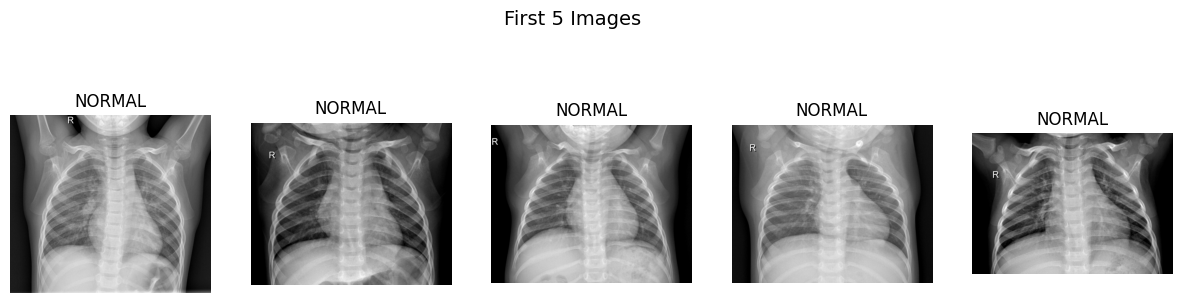

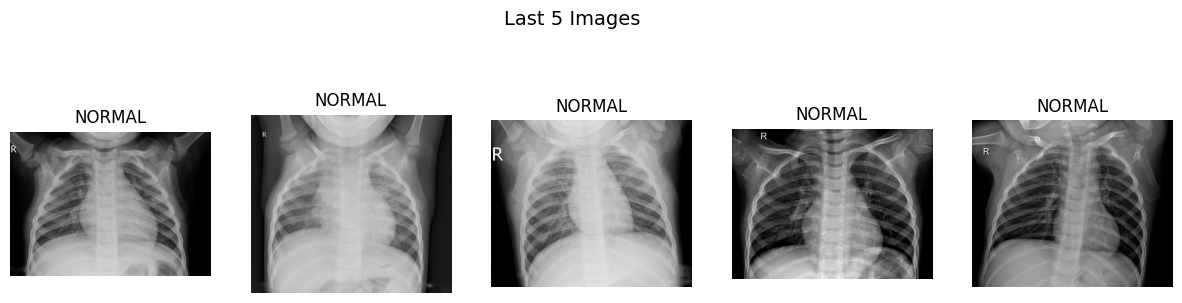

In [11]:
def show_images(file_list, title):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=14)
    for i, filepath in enumerate(file_list):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_jpeg(img, channels=3)
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        label = "PNEUMONIA" if "PNEUMONIA" in filepath else "NORMAL"
        plt.title(label)
        plt.axis("off")
    plt.show()

show_images(filenames[:5], "First 5 Images")
show_images(filenames[-5:], "Last 5 Images")

In [15]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
IMAGE_SIZE = [180, 180]   # matches source
BATCH_SIZE = 16           # matches source

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2] == "PNEUMONIA"

def decode_img(img):
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.image.resize(img, IMAGE_SIZE)

def process_path(file_path):
    label = get_label(file_path)
    label = tf.cast(label, tf.float32)
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

train_ds = train_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds   = val_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)

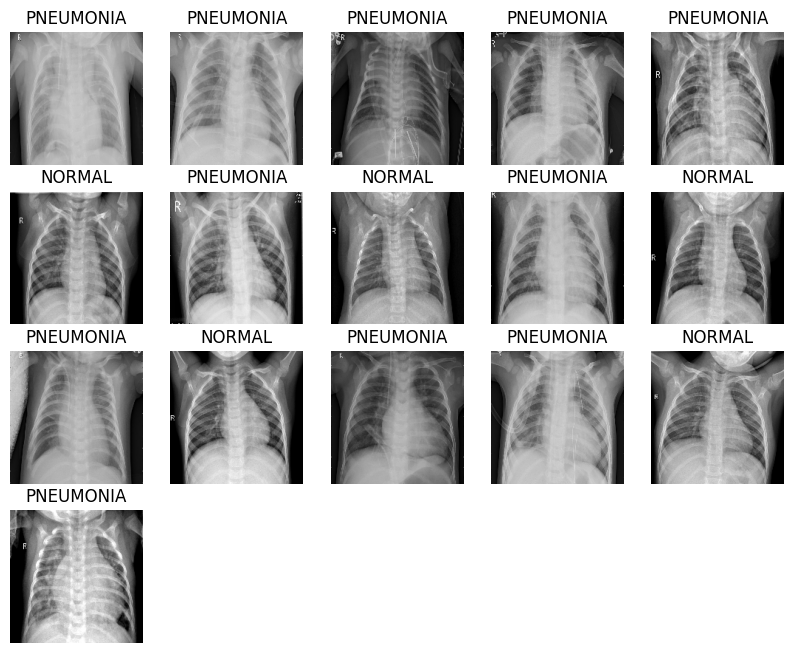

In [16]:
def prepare_for_training(ds, cache=True, shuffle_buffer_size=1000):
    if cache:
        ds = ds.cache() if cache is True else ds.cache(cache)
    ds = ds.repeat()
    ds = ds.shuffle(buffer_size=shuffle_buffer_size)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare_for_training(train_ds)
val_ds   = prepare_for_training(val_ds)

image_batch, label_batch = next(iter(train_ds))
image_batch = image_batch.numpy()
label_batch = label_batch.numpy()

def show_batch(image_batch, label_batch):
    plt.figure(figsize = (10,10))
    n_show = min(25, image_batch.shape[0])
    for n in range(n_show):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(image_batch[n])
        plt.title("PNEUMONIA" if label_batch[n] > 0.5 else "NORMAL")
        plt.axis("off")

show_batch(image_batch, label_batch)


In [17]:
def conv_block(filters):
    block = tf.keras.Sequential([
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D()
    ])
    return block

def dense_block(units, dropout_rate):
    block = tf.keras.Sequential([
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(dropout_rate)
    ])
    return block

def build_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(),

        conv_block(32),
        conv_block(64),

        conv_block(128),
        tf.keras.layers.Dropout(0.2),

        conv_block(256),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Flatten(),
        dense_block(512, 0.7),
        dense_block(128, 0.5),
        dense_block(64, 0.3),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [18]:
initial_bias = np.log([COUNT_PNEUMONIA / COUNT_NORMAL])
weight_for_0 = (1 / COUNT_NORMAL) * (TRAIN_IMG_COUNT) / 2.0
weight_for_1 = (1 / COUNT_PNEUMONIA) * (TRAIN_IMG_COUNT) / 2.0

class_weight = {0: weight_for_0, 1: weight_for_1}
print("Weight for class 0:", weight_for_0)
print("Weight for class 1:", weight_for_1)

model = build_model()

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=METRICS
)

Weight for class 0: 1.9759206798866857
Weight for class 1: 0.6693857965451055


In [19]:
EPOCHS = 25

history = model.fit(
    train_ds,
    steps_per_epoch=TRAIN_IMG_COUNT // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    validation_steps=VAL_IMG_COUNT // BATCH_SIZE,
    class_weight=class_weight
)

Epoch 1/25
 49/261 ━━━━━━━━━━━━━━━━━━━━ 1:41 478ms/step - accuracy: 0.6188 - loss: 0.6976 - precision: 0.8313 - recall: 0.5843

KeyboardInterrupt: 

In [11]:
test_list_ds = tf.data.Dataset.list_files(os.path.join(TEST_DIR, "*", "*"))
TEST_IMAGE_COUNT = tf.data.experimental.cardinality(test_list_ds).numpy()

test_ds = test_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)

loss, acc, prec, rec = model.evaluate(test_ds)
print("Test accuracy:", acc)
print("Test precision:", prec)
print("Test recall:", rec)

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8003 - loss: 0.8555 - precision: 0.7578 - recall: 0.9964
Test accuracy: 0.8044871687889099
Test precision: 0.7648221254348755
Test recall: 0.9923076629638672
